In [1]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu
import importlib as il

In [2]:
# configure the backend for matplotlib
# this one should allow zoom:
# %matplotlib widget
# to make that work you need: "pip install ipympl" and run "jupyter nbextension enable --py widgetsnbextension"

# this will work without the above dependencies but won't allow zoom
%matplotlib inline

# this option may work whenever they fix bugs in mpld3
# import mpld3
# mpld3.enable_notebook()

In [3]:
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

Running model: 2D from bottom
   Relaxed 2 variables on 2D from bottom
   Loop: 1 , Relaxed score: 2.3333333333333335
Added simple bound cuts: 1
   Loop: 2 , Relaxed score: 2.0


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

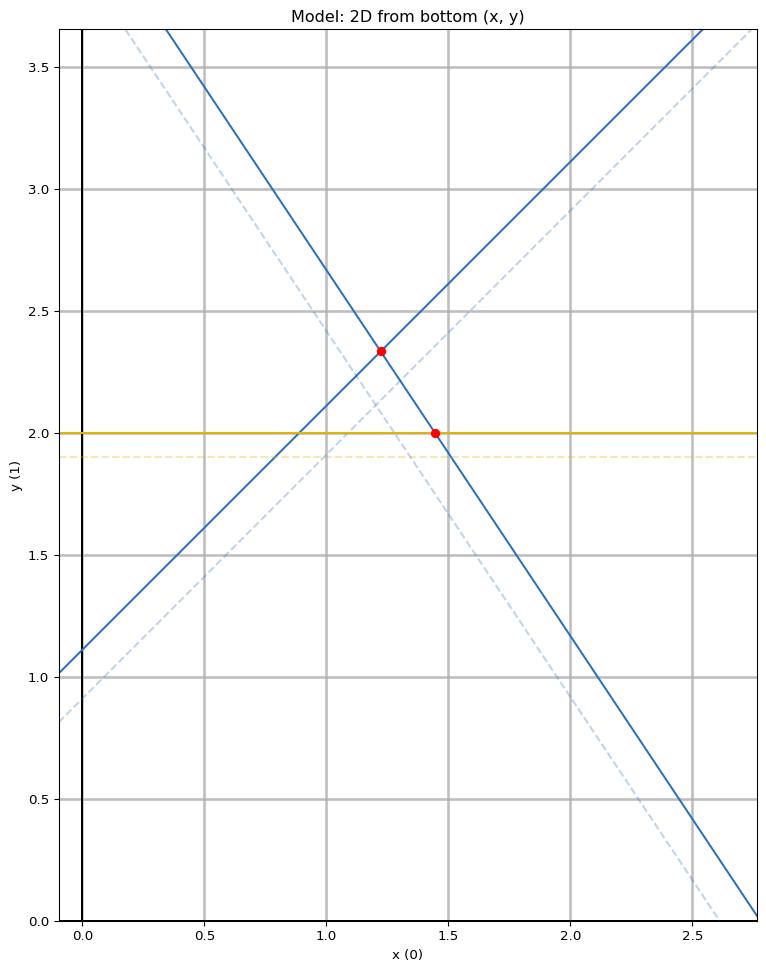

In [ ]:
import importlib as il
import numpy as np
import gurobipy as gp

il.reload(el)
il.reload(gu)
il.reload(pu)

def find_unimodular(tableau, row, tol):
    n = tableau.shape[1]
    result = np.zeros((n, n), dtype=np.int32)
    for i in range(n):
        result[i, i] = 1 if tableau[row, i] >= 0 else -1
    return result

def get_coeffs(expr: gp.LinExpr, variable):
    s = 0.0
    for i in range(expr.size()):
        if expr.getVar(i).index == variable.index:
            s += expr.getCoeff(i)
    return s

# A function to create cuts given a target point
def add_cut(relaxed: gp.Model, integer_vars, integer_idx, plotter):
    
    if plotter is not None:
        plotter.add_ball(1.2)

    tol = relaxed.params.FeasibilityTol
    all_done = True
    for iv in integer_vars:
        x = iv.X.item()
        if not np.isclose(x, round(x), atol=tol):
            all_done = False
            break
    if all_done:
        return False
    
    variables = relaxed.getVars()  # TODO: pass this in as it's expensive?
    constraints = relaxed.getConstrs()  # wish we didn't have to use this one
    
    def find_variable(index):
        if index < len(variables):  # variables is from model.getVars()
            # handle inverted variables (SCIP and Gurobi both have this silliness)
            match variables[index].VBasis:
                case gp.GRB.SUPERBASIC:
                    raise NotImplementedError("Not yet handling SUPERBASIC") 
                case gp.GRB.NONBASIC_UPPER:
                    return variables[index].UB - variables[index]
                case gp.GRB.NONBASIC_LOWER:
                    return variables[index] - variables[index].LB
                case _:
                    return variables[index]
        # if only gurobi gave us access to their slack variables...
        # instead, we have to solve for it:
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        lhs, sense, rhs = relaxed.getRow(constraint), constraint.Sense, constraint.RHS
        if sense == '<':
            return rhs - lhs
        elif sense == '>':
            return lhs - rhs
        else:
            return 0.0  # Gurobi has slacks on equality constraints, but they must always be 0
        
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=0)
    negated_vars = [basis[nr] for nr in negated_rows]

    # the current understanding (from nlhdlr_quadratic.c in SCIP): 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    for col, j in enumerate(col_to_var_idx):
        if j < len(variables):
            # print("Var INFO:", variables[j].VarName, "VBasis", variables[j].VBasis, "LB", variables[j].LB, "UB", variables[j].UB)
            if variables[j].VBasis == -2:
                tableau[:, col] = -tableau[:, col]
        else:
            constraint = constraints[j - len(variables)]
            if constraint.Sense == '>':  # Achterberg said lt and lte are standard; should just need to flip gt
                tableau[:, col] = -tableau[:, col]

    # if tableau.shape[0] * tableau.shape[1] < 100:
    #     failures = gu.validate_corner(relaxed, basis, tableau, col_to_var_idx)
    #     assert failures == 0
    tableau = -tableau
    # colors = ['xkcd:salmon', 'xkcd:orange']
    # for col, j in enumerate(col_to_var_idx):
    #     xpr: gp.LinExpr = 0.0
    #     for i, b in enumerate(basis):
    #         xpr += tableau[i, col] * find_variable(b)
    #     xv = get_coeffs(xpr, variables[0]) * 0.1 + variables[0].X
    #     yv = get_coeffs(xpr, variables[1]) * 0.1 + variables[1].X
    #     plotter.add_point([xv, yv], color=colors[col % len(colors)])        

    # drop the rows of non-integer variables:
    to_drop = [i for i, b in enumerate(basis) if b not in integer_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop) # update basis to match tableau

    non_zero_columns = ~np.all(np.abs(tableau) <= tol, axis=0)
    tableau = tableau[:, non_zero_columns]
    col_to_var_idx = col_to_var_idx[non_zero_columns]

    # drop all rows that are non-fractional:
    tol = relaxed.params.IntFeasTol
    # to_drop = [i for i, b in enumerate(basis) if np.isclose(x[integer_idx[b]], round(x[integer_idx[b]]), tol)]
    # tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    # basis = np.delete(basis, to_drop)
    # x_idx = [integer_idx[b] for b in basis]

    to_cut = [(i, b, integer_vars[integer_idx[b]].X.item()) for i, b in enumerate(basis)  # can't call find_var_value after addConstr or update
            if b in integer_idx and tol < (integer_vars[integer_idx[b]].X.item() % 1) < 1.0-tol]
    
    cuts = []
    for row, base, x in to_cut:
        # print("Row", row, "Base", base, "X", x, "Slack", constraints[row].Slack)
        # if not np.isclose(constraints[row].Slack, 0.0, atol=tol):
        #     tableau[row] = -tableau[row]
        if np.all(np.isclose(tableau[row], 0.0, atol=tol)):
            print("Warning! Empty row", row)
            continue
        elif np.all(tableau[row] >= -tol):
            # find_variable(base).LB = np.ceil(x)
            cuts.append(find_variable(base) >= np.ceil(x))
        elif np.all(tableau[row] <= tol):
            cuts.append(find_variable(base) <= np.floor(x))
            
    if len(cuts) > 0:
        print("Added simple bound cuts:", len(cuts))
        for cut in cuts: 
            bc = relaxed.addConstr(cut)
            if plotter is not None:
                relaxed.update()
                plotter.add_constraint(bc)
        return True

    col_vars = [find_variable(c) for c in col_to_var_idx]
    # tableau2 = 1 - tableau2
    # TODO: things to correct here:
    # 1. this 1 + ... code 
    # 2. my drawing of the constraints needs to sample y given x and vice-versa
    # 3. I never did figure out the right slack addition for verification
    # 4. We could do a separate transform for each row; why not? And we could just read rows of interest
    # for col, j in enumerate(col_to_var_idx):
    #     if j < len(variables):
    #         if variables[j].VBasis == -2:
    #             tableau[:, col] = variables[j].UB + tableau[:, col]
    u: np.ndarray = find_unimodular(tableau, to_cut[0][0], tol)
    tableau2 = tableau @ u
    ui = np.linalg.inv(u)
    # assert ui == u
    # col_vars = ui @ col_vars

    for row, base, x in to_cut:
        if np.all(np.isclose(tableau2[row], 0.0, atol=tol)):
            print("Warning! Empty row", row)
            continue  # TODO: I don't really want this to be possible
        elif np.all(tableau2[row] >= -tol):
            # does it work when all variables are basis variables?
            # do I need to transform the variables that correspond to columns in my transformed tableau?
            # or to rows? the transformed tableau should give different RHS values, no?
            # cuts.append((it2[row] @ col_vars >= np.ceil(x) - x, 'xkcd:teal'))
            # cuts.append(((u.T @ tableau[row]).T @ col_vars >= np.ceil(x) - x, 'xkcd:teal'))
            # cuts.append((x - tableau2[row] @ col_vars <= np.floor(x), 'xkcd:teal'))
            # cuts.append((x + tableau2[row] @ col_vars >= np.ceil(x), 'xkcd:berry'))
            # oversimplified for the moment:
            # if relaxed.ModelSense == gp.GRB.MAXIMIZE:
            #     cuts.append((x - tableau2[row] @ col_vars <= np.floor(x), 'xkcd:teal'))
            # else:
            cuts.append((x + tableau2[row] @ col_vars) @ ui[] >= np.ceil(x), 'xkcd:berry'))
        elif np.all(tableau2[row] <= tol):
            # if relaxed.ModelSense != gp.GRB.MAXIMIZE:
            #     cuts.append((x - tableau2[row] @ col_vars >= np.ceil(x), 'xkcd:orange'))
            # else:
            cuts.append((x + tableau2[row] @ col_vars) <= np.floor(x), 'xkcd:brown'))
            # elif np.all(tableau2[row] <= tol):
            # cuts.append((x + tableau2[row] @ col_vars >= np.ceil(x), 'xkcd:berry'))
            # cuts.append((x - tableau2[row] @ col_vars <= np.floor(x), 'xkcd:teal'))
        
        if False:  # do the split cut
            points = []
            for col, ray in enumerate(tableau.T):
                rr = ray[row]
                # if row in negated_rows:
                #     rr = -rr
                if np.isclose(rr, 0, atol=tol):
                    continue
                scale = -rr / (x % 1) if rr < 0 else rr / (1-(x % 1))
                # print("SCALE", scale, x, rr)
                # point = basis_corner.copy()
                # point[basis] += scale * ray[:-1]
                # point[r] += scale * ray[-1]
                # print("INFO", row, col, base, x, ray, scale)

                points.append((find_variable(col_to_var_idx[col]), scale))
            if points:
                summed_terms = gp.quicksum(nrm * v for v, nrm in points)
                cuts.append((summed_terms >= 1, 'xkcd:pink'))

    if len(cuts) > 0:
        print("Added simple bound cuts after transform:", len(cuts))
        for cut, color in cuts: 
            bc = relaxed.addConstr(cut)
            if plotter is not None:
                relaxed.update()
                plotter.add_constraint(bc, color)
        return True

    return False

def run_cuts_to_relaxed_sol(instances, loops=8, graph_2D_3D=True):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        model.update()
        plotter = pu.create(model) if graph_2D_3D else None
        # gu.standardize_gt_to_lt(model)
        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break

            print("   Loop:", i+1, ", Relaxed score:", model.getObjective().getValue())
            if not add_cut(model, int_vars, int_idx, plotter):
                print("   Done! All constraints met.")
                break

        print("   Known best score:", instance.score if instance.known_optimum else "unknown")    
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples (5-8 don't draw all cuts correctly): fails: 1, 3
run_cuts_to_relaxed_sol(list(el.get_instances(env).values())[0:3], loops=2)

In [ ]:
miplib_instances = ml.get_instances()
miplib_subset = [miplib_instances['air05'], miplib_instances['markshare2']]  # mas76
run_cuts_to_relaxed_sol(miplib_subset[0:1])

In [74]:
import jsplib_loader as jl
jsplib_instances = jl.get_instances()
jsplib_subset = [jsplib_instances['abz4']]
run_cuts_to_relaxed_sol(jsplib_subset, loops=500)

Set parameter AggFill to value 10
Set parameter GomoryPasses to value 1
Running model: abz4
Set parameter LogToConsole to value 0
   Relaxed 216 variables on abz4
   Loop: 1 , Relaxed score: 505.0
Added simple bound cuts after transform: 52
   Loop: 2 , Relaxed score: 508.2230396003054
Added simple bound cuts after transform: 43
   Loop: 3 , Relaxed score: 589.1404202664414
Added simple bound cuts after transform: 42
   Loop: 4 , Relaxed score: 593.3628174332823
Added simple bound cuts after transform: 43
   Loop: 5 , Relaxed score: 602.5184494754415
Added simple bound cuts after transform: 44
   Loop: 6 , Relaxed score: 604.9856597094661
Added simple bound cuts after transform: 44
   Loop: 7 , Relaxed score: 607.767811468907
Added simple bound cuts after transform: 45
   Loop: 8 , Relaxed score: 608.7895680965971
Added simple bound cuts after transform: 41
   Loop: 9 , Relaxed score: 608.9012033669532
Added simple bound cuts after transform: 39
   Loop: 10 , Relaxed score: 610.0001369

KeyboardInterrupt: 